#**1. Problem Statement, Context, and Objective**


---

##1.1 Problem Statement

Financial institutions process enormous volumes of transactions every day, and only a very small fraction of these are fraudulent. This project addresses the problem of identifying fraudulent card transactions within a highly imbalanced dataset, where fraudulent transactions represent less than one percent of all activity. The core challenge is not simply building a model that performs well overall, but building one that can reliably catch the rare fraudulent cases without overwhelming the system with false alarms.

##1.2 Context

This project uses a dataset of simulated card transactions, covering everyday spending categories such as groceries, entertainment, travel, and personal care, with each transaction linked to details about the customer, the merchant, the amount, and the time it occurred. Out of 80,000 transactions in this dataset, only about 0.52 percent are labeled as fraudulent, which reflects the reality of fraud detection, the cases that matter most are also the rarest, making them easy for a model to overlook if not evaluated carefully.

##1.3 Objective

The objective is to thoroughly explore and understand the transaction data, prepare it appropriately for modeling, engineer features that could reveal fraudulent behavior, and build and compare multiple classification models, ultimately selecting the one that best identifies fraudulent transactions without simply optimizing for overall accuracy.

##2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

##3. Load Dataset

In [ ]:
fraud_data = pd.read_csv('/content/fraud_sample.csv')
fraud_data

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,226080,2019-04-24 10:46:45,348379466427142,"fraud_Willms, Kris and Bergnaum",shopping_pos,5.46,Michael,Rowe,M,7428 Martinez Flats,...,28.1384,-80.6524,139650,Database administrator,1957-01-23,651afd13a2b29f6222c0fb9c672732e5,1.335264e+09,28.157716,-80.640446,0.0
1,819475,2019-12-08 17:26:31,581293083266,fraud_Nienow PLC,entertainment,67.29,William,Thomas,M,39227 Mcpherson Shoals,...,36.3850,-98.0727,1078,Podiatrist,1989-10-06,098876010ff74cdc5e1561bb1a485357,1.354988e+09,36.777249,-98.396662,0.0
2,867073,2019-12-19 11:40:21,3577578023716568,fraud_Kuphal-Bartoletti,misc_net,60.68,Debbie,Hughes,F,0182 Owens Burgs Suite 480,...,41.0935,-81.0425,2644,"Engineer, biomedical",1983-08-25,1fb22cfe578e78c3125c5c23c5720248,1.355917e+09,41.247296,-80.198870,0.0
3,443759,2019-07-16 09:37:24,4807552641361,fraud_Eichmann-Russel,misc_pos,4.71,Kimberly,Castro,F,588 Smith Lights Suite 786,...,40.2158,-83.9579,133,Professor Emeritus,1954-01-29,a166f02d6dad8c51d330e9cdfe689866,1.342431e+09,40.490822,-84.828330,0.0
4,158665,2020-08-16 06:57:49,630423337322,fraud_Bernhard Inc,gas_transport,69.32,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,9eba7becfc7559d4d59585abbba17b0a,1.376636e+09,48.720297,-117.597733,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78453,1064721,2020-03-17 16:50:18,6524376634971418,"fraud_Wuckert, Wintheiser and Friesen",home,67.37,Jasmine,Foster,F,954 White Alley Apt. 251,...,34.3470,-87.7154,5778,"Engineer, aeronautical",1952-12-05,fa992b80fa16dfe267ef93a6cba4d8bf,1.363539e+09,34.230433,-87.959826,0.0
78454,717288,2019-11-02 19:31:59,4378993458389626,fraud_Osinski Inc,personal_care,75.23,Travis,Hayes,M,1561 Chase Grove,...,43.9742,-71.1503,3807,Surgeon,1999-10-25,c87860f1577100ec77fb8140899a773b,1.351885e+09,44.799423,-71.860458,0.0
78455,917097,2019-12-30 05:44:19,4488258847705225890,fraud_Koelpin and Sons,misc_net,3.30,Jessica,Shaw,F,5745 Blair Locks,...,33.9568,-81.1405,52126,Chemical engineer,1929-08-23,01da5368407922061b0bca426c8c5926,1.356846e+09,34.691750,-81.696280,0.0
78456,629555,2019-09-24 14:19:16,4562827002127,"fraud_Towne, Greenholt and Koepp",shopping_net,3144.69,Christopher,Johnson,M,28711 Kristine Junction Suite 309,...,40.0987,-84.6342,22930,Media planner,1971-11-26,89b448ae164de1bc48586e2d4c31e4a6,1.348496e+09,40.672572,-83.871577,0.0


##4. Dataset Overview

In [ ]:
display(fraud_data.shape)
display(fraud_data.columns)
display(fraud_data.dtypes)
display(fraud_data.sample(10))

(78458, 23)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

,0
Unnamed: 0,int64
trans_date_trans_time,object
cc_num,int64
merchant,object
category,object
amt,float64
first,object
last,object
gender,object
street,object


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
58345,527661,2019-08-15 14:37:33,4198470814557,fraud_Padberg-Sauer,home,14.03,Christie,Williamson,F,519 Jerry Views,...,41.4768,-95.3509,2036,Engineering geologist,1971-08-20,8f20256b1bdbc67efed391f5b4337813,1.345041e+09,40.752034,-94.676877,0.0
58835,82825,2020-07-20 06:36:00,4319584480204988982,"fraud_Douglas, Schneider and Turner",shopping_pos,870.49,Kathleen,Nash,F,010 Salazar Walk,...,37.1788,-82.6950,502,Chief Financial Officer,1960-02-01,82b8733ea8009a38ee000b061503f203,1.374302e+09,36.946145,-82.425082,0.0
47409,531348,2020-12-26 23:29:28,180094419304907,"fraud_Towne, Greenholt and Koepp",shopping_net,100.79,Sharon,Smith,F,17666 David Valleys,...,33.7467,-117.1721,54287,"Designer, exhibition/display",1972-09-22,49458a09d065ba7be88e3918a7ba6798,1.388101e+09,33.461067,-117.157972,0.0
16594,75394,2019-02-13 22:48:02,4181833256558613886,"fraud_Monahan, Bogisich and Ledner",misc_pos,210.50,Jessica,Potter,F,7600 Stephen Course Suite 031,...,36.6659,-105.4694,606,"Surveyor, land/geomatics",1988-09-06,3d0b63ae18cb222421c46780599dcb54,1.329173e+09,37.606246,-104.617792,0.0
40790,1061946,2020-03-16 19:11:04,4633065159406313,"fraud_Hahn, Bahringer and McLaughlin",personal_care,157.25,Jasmine,Wade,F,90662 Lewis Avenue,...,41.8383,-71.4377,203571,"Nurse, children's",1995-11-29,f0140a4e68e3b7dc1ff5ddc639c1e56a,1.363461e+09,41.183085,-70.444370,0.0
28861,209567,2019-04-17 00:05:11,5501083170975659,fraud_Block Group,misc_pos,5.12,Wayne,Payne,M,587 Bradley Inlet Suite 281,...,41.1464,-81.5107,47772,Equities trader,1966-01-04,878b2c4217792552fa273a471107af08,1.334621e+09,40.873153,-81.571495,0.0
75081,1235153,2020-05-30 20:20:06,2383461948823908,"fraud_Hermiston, Pacocha and Smith",health_fitness,6.13,Patrick,Vaughan,M,651 Miller Common,...,43.7450,-70.9092,1892,Audiological scientist,1956-03-02,6b265f6fa702b3706dcac9f6f6da94fb,1.369945e+09,43.982380,-71.227471,0.0
63015,800250,2019-12-04 09:18:18,5540636818935089,fraud_Runolfsson and Sons,grocery_net,36.90,Kenneth,Foster,M,329 Michael Extension,...,42.6911,-71.1605,76383,Geoscientist,1985-04-04,e015fc169b6719d9a24bbdfcdf51eaf1,1.354613e+09,43.546607,-72.053884,0.0
70545,193372,2020-08-28 09:33:44,3538520143479972,"fraud_Quitzon, Green and Bashirian",shopping_pos,1.30,Cassandra,Nunez,F,9572 Austin Forge Suite 612,...,41.5686,-83.3632,269,Insurance underwriter,1965-09-15,7b71847ca02120a1e151c20e4270eada,1.377682e+09,40.661709,-82.373863,0.0
13599,168724,2020-08-18 22:43:44,4890424426862856940,fraud_Christiansen-Gusikowski,misc_pos,1.22,Jeremy,Whitney,M,0371 Aimee Neck Suite 856,...,38.5662,-121.3286,757530,Magazine features editor,1979-04-30,3df4a89a7771597917c0ccb96baba380,1.376866e+09,39.551037,-122.200185,0.0


####Findings

The dataset consists of 80,000 rows and 23 columns.

Most columns have an object datatype, however, Unnamed:0, cc_num, zip, city_pop, unix_time and is_fraud has an integer data type while amt, lat, long, merch_lar, merch_long has a float data type.

##5. Exploratory Data Analysis

###5.1 Target Variable
a. What proportion of transactions in is_fraud are fraudulent versus legitimate?

b. How severe is the class imbalance, and how does this determine the evaluation of the models later?

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
147,295650,2020-10-10 23:41:20,4104312520615374,"fraud_Schneider, Hayes and Nikolaus",food_dining,125.67,Brooke,Rodriguez,F,901 Todd Gardens Apt. 466,...,33.6401,-116.5567,1661,"Therapist, music",1988-09-19,92cfb8521b5dda388554d6539e16a8bd,1.381448e+09,33.567048,-115.702036,1.0
165,1290364,2020-06-18 22:25:12,4610064888664703,fraud_Fisher Inc,shopping_net,1053.08,Tammy,Maldonado,F,3312 Rachel Parks Suite 474,...,43.2229,-75.2899,847,Systems analyst,1996-01-11,0f0c2d7613c1fc9957b7e6ac4566af7d,1.371594e+09,42.950274,-76.200365,1.0
411,1290569,2020-06-19 00:27:11,36890292963032,fraud_Friesen-Stamm,gas_transport,20.15,Kimberly,Webb,F,380 Martin Mission,...,33.0437,-81.7106,1100,"Conservator, museum/gallery",1950-04-05,f236fc296a16f93b8ef9c550ecab039b,1.371602e+09,32.115871,-82.061893,1.0
485,310093,2020-10-17 04:51:52,30570197515105,fraud_Koepp-Parker,grocery_pos,290.91,Vincent,Cain,M,64851 Cole Turnpike,...,31.0860,-85.7192,5732,Jewellery designer,1945-12-07,dfe695ac87cc2acf74ffd9c70ce72e96,1.381986e+09,30.803422,-85.859030,1.0
526,150831,2019-03-22 16:17:14,4180192513916047166,"fraud_Medhurst, Labadie and Gottlieb",travel,10.23,Brian,Ray,M,055 Stephanie Turnpike Suite 559,...,36.1800,-80.1629,7369,TEFL teacher,1927-02-03,1fabc902dd69134b361e88184c439492,1.332433e+09,36.452416,-79.671106,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77283,272829,2019-05-14 23:32:39,3575540972310993,fraud_Jacobi and Sons,shopping_pos,936.42,Rachel,Villarreal,F,250 Carrie Throughway,...,34.3396,-89.5736,4198,Curator,2001-06-22,53bafe4a1a44871ca07f35bf21c2532e,1.337038e+09,34.548939,-90.335814,1.0
77548,59672,2019-02-04 22:16:37,4451952084362894,fraud_Koepp-Parker,grocery_pos,290.79,Joseph,Davis,M,941 Adam Stravenue,...,34.5444,-102.1069,686,Petroleum engineer,1980-07-30,2ede9135571a64f21385087de2f118ef,1.328394e+09,34.670730,-102.423796,1.0
77803,931069,2020-01-05 01:38:51,3523843138706408,"fraud_Weimann, Kuhic and Beahan",shopping_pos,799.00,Grace,Williams,F,28812 Charles Mill Apt. 628,...,32.6176,-86.9475,1412,Drilling engineer,1970-11-20,77cdde19fa122f694202093b72b16dd5,1.357350e+09,33.190072,-87.490798,1.0
78217,1142572,2020-04-20 23:57:19,348379466427142,"fraud_Goldner, Kovacek and Abbott",grocery_pos,280.21,Michael,Rowe,M,7428 Martinez Flats,...,28.1384,-80.6524,139650,Database administrator,1957-01-23,adb5cd0937019223c25a5724fd5c30aa,1.366502e+09,27.949518,-79.884457,1.0


,proportion
is_fraud,
0.0,99.47997
1.0,0.52003


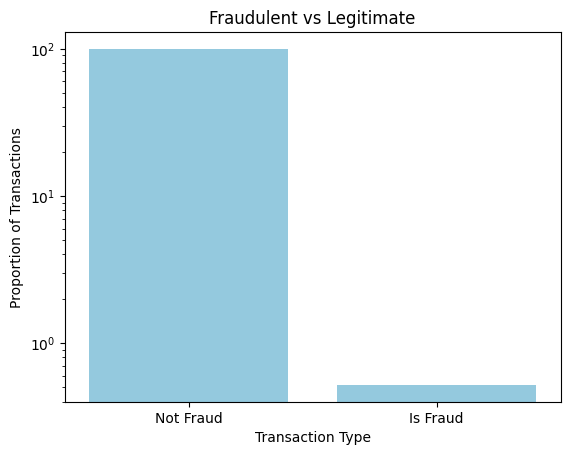

In [ ]:
transact_fraud = fraud_data.loc[fraud_data["is_fraud"]==1]
transact_propor = fraud_data['is_fraud'].value_counts(normalize=True) * 100
display(transact_fraud)
display(transact_propor)

sns.barplot(x = transact_propor.index, y = transact_propor.values, color='skyblue')
plt.xticks(transact_propor.index, ["Not Fraud", "Is Fraud"])
plt.xlabel("Transaction Type")
plt.ylabel("Proportion of Transactions")
plt.yscale("log")
plt.title("Fraudulent vs Legitimate")
plt.show()

####Findings

Out of 80,000 transactions, 417 transactions are discovered to be fraudulent which leave 79,583 legitimate transactions. The class imbalance is extreme because only 0.52125 of the dataset contains fraudulent transaction, therefore, other metrics for model evaluation will be considered due to the imbalanced classification as a high accuracy given by a model could be misleading.

###5.2 Transaction Characteristics

a. What does the distribution of amt look like overall, and is it skewed?

b. Do fraudulent transactions tend to involve higher, lower, or similar amounts compared to legitimate ones?

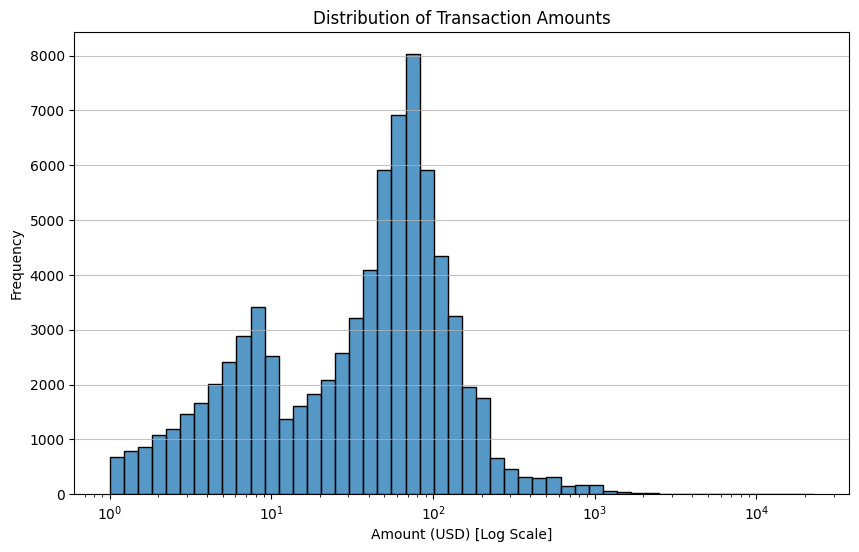

,min,max,mean
,amt,amt,amt
is_fraud,,,
0.0,1.00,22768.11,68.360544
1.0,5.44,1197.23,545.451716


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(fraud_data['amt'], bins=50, log_scale = True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount (USD) [Log Scale]')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


summ_amts = fraud_data.pivot_table(
           values = "amt",
           index = "is_fraud",
           aggfunc = ["min", "max", "mean" ]
)
display(summ_amts)

###Findings

Transaction amounts are heavily right-skewed, with most purchases under $100 and a smaller number extending into the thousands. On a log scale, two distinct spending clusters appear, suggesting more than one common purchase pattern in the data.

Fraudulent transactions  has an average 545.20 which is higher than the average for legitimate ones(68.3), suggesting amount carries real predictive signal. That said, the single largest transaction overall which is 22,768.11 was a legitimate transaction while the largest fraud case topped out at 1,197.23, so high amount alone does not guarantee fraud.

c. Which values in category appear most and least frequently in the dataset?

d. Are certain categories disproportionately associated with fraud, or is fraud spread evenly across categories?

In [ ]:
cat_freq = fraud_data['category'].value_counts()
display(cat_freq)

category_fraud_rate = fraud_data.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
print(category_fraud_rate)

,count
category,
gas_transport,8066
grocery_pos,7520
home,7304
shopping_pos,7068
kids_pets,6841
shopping_net,5801
entertainment,5778
food_dining,5554
personal_care,5424


category
misc_net          1.711688
shopping_net      1.654887
grocery_pos       1.196809
shopping_pos      0.580079
gas_transport     0.483511
misc_pos          0.263318
kids_pets         0.248538
travel            0.199283
health_fitness    0.194137
personal_care     0.165929
home              0.150602
entertainment     0.121149
grocery_net       0.108460
food_dining       0.054015
Name: is_fraud, dtype: float64


####Findings

The category "gas transport" appears the most in this dataset, meaning that most transactions involves purchases in this category while the category "travel" appears the least in this dataset meaning that the least transactions involves purchases in this category.

The column "misc_net"  has the highest fraud rate at 1.71 percent, followed by shopping_net at 1.64 percent and grocery_pos at 1.21 percent. This shows that online and card-present retail categories appear to carry meaningfully higher fraud risk than everyday routine spending categories.

###5.3 Time Patterns

a. Using trans_date_trans_time, at what hours of the day do transactions happen most often?

b. Do fraudulent transactions cluster around specific hours, such as late at night, compared to legitimate ones?

Transactions by Hour:


,count
trans_date_trans_time,
0,2557
1,2653
2,2562
3,2636
4,2548
5,2502
6,2622
7,2591
8,2530


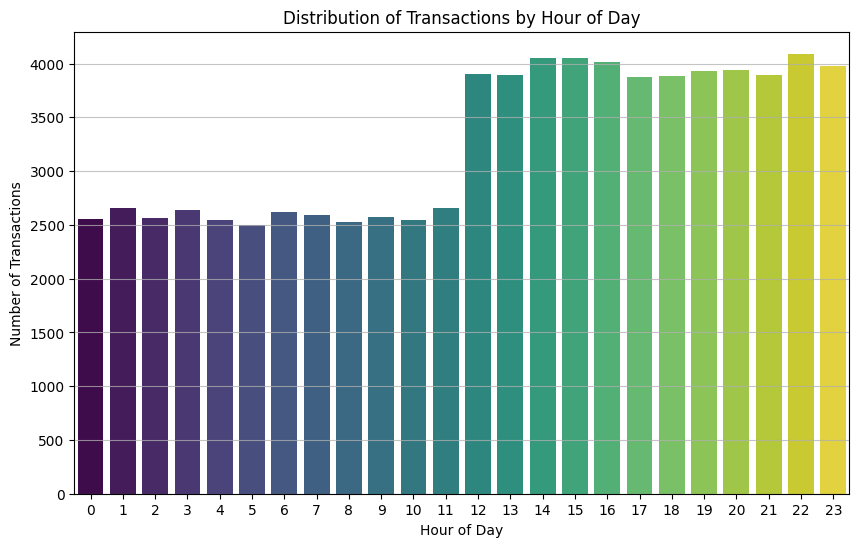

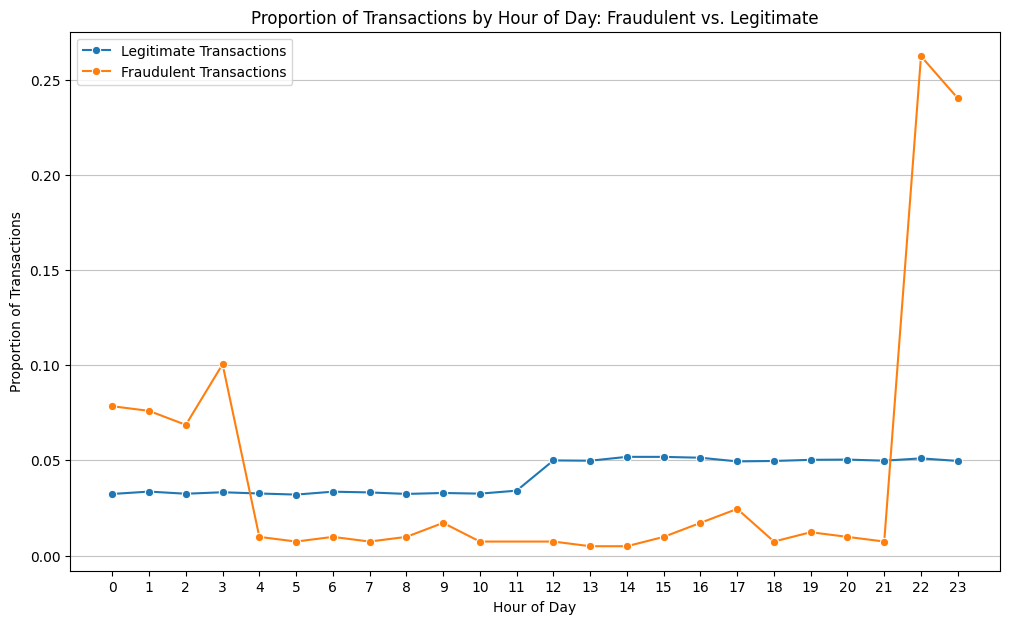

In [ ]:
fraud_data['trans_date_trans_time'] = pd.to_datetime(fraud_data['trans_date_trans_time'], format='mixed')
fraud_data['hour'] = fraud_data['trans_date_trans_time'].dt.hour
transaction_hour = fraud_data['trans_date_trans_time'].dt.hour

hour_counts = transaction_hour.value_counts().sort_index()
print("Transactions by Hour:")
display(hour_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette='viridis', hue=hour_counts.index, legend=False)
plt.title('Distribution of Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.75)
plt.show()


fraudulent_transactions = fraud_data[fraud_data['is_fraud'] == 1]
legitimate_transactions = fraud_data[fraud_data['is_fraud'] == 0]

fraud_hour_counts = fraudulent_transactions['trans_date_trans_time'].dt.hour.value_counts().sort_index()
legit_hour_counts = legitimate_transactions['trans_date_trans_time'].dt.hour.value_counts().sort_index()

fraud_hour_proportion = fraud_hour_counts / fraud_hour_counts.sum()
legit_hour_proportion = legit_hour_counts / legit_hour_counts.sum()

plt.figure(figsize=(12, 7))
sns.lineplot(x=legit_hour_proportion.index, y=legit_hour_proportion.values, label='Legitimate Transactions', marker='o')
sns.lineplot(x=fraud_hour_proportion.index, y=fraud_hour_proportion.values, label='Fraudulent Transactions', marker='o')
plt.title('Proportion of Transactions by Hour of Day: Fraudulent vs. Legitimate')
plt.xlabel('Hour of Day')
plt.ylabel('Proportion of Transactions')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

####Findings

Most transactions tends to occur from afternoon till evening rather than midnight, with most transactions happening at the fourteenth(2:00pm), twenty-second(9:00pm) and eighteenth hour(7:00pm).

The legitimate transactions has a steady occurence throughout the day while most fraudulent transactions tends to happen late at night and in the middle of the night.

c. Does the day of the week show any difference in fraud rate?

d. Does fraud rate change across the months covered in the dataset, or does it stay roughly constant?

Fraud Rate by Day of Week:


,is_fraud
day_of_week,
0,0.443993
1,0.466590
2,0.687460
3,0.618951
4,0.531915
5,0.541223
6,0.469581



Fraud Rate by Month:


,is_fraud
month,
1,0.928793
2,0.670659
3,0.771377
4,0.497769
5,0.735540
6,0.536082
7,0.361262
8,0.412618
9,0.516065


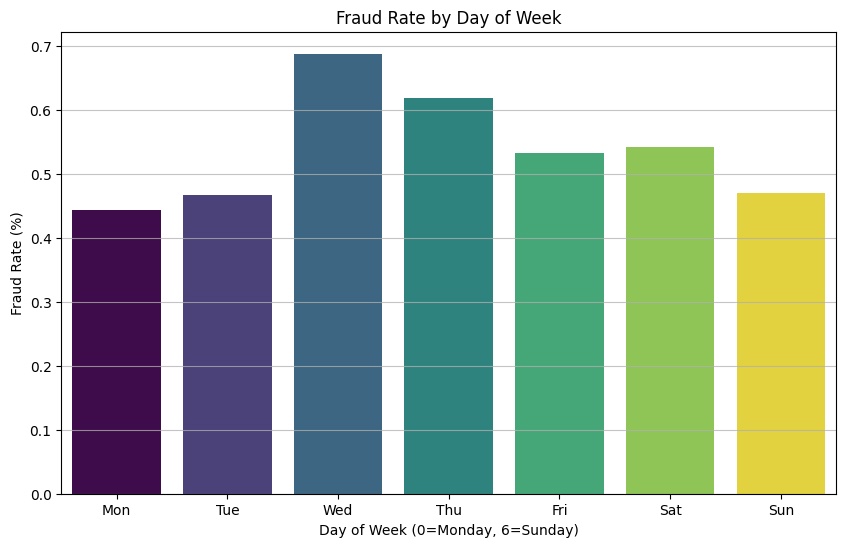

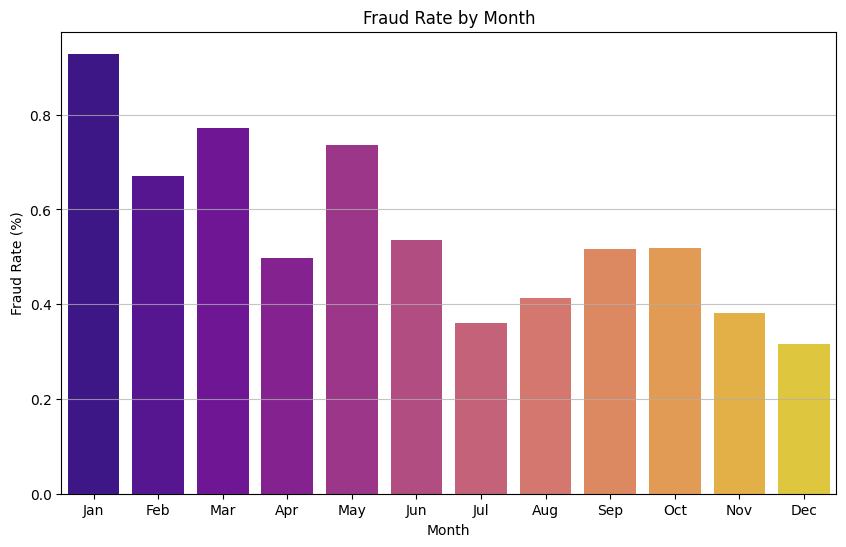

In [ ]:
fraud_data['day_of_week'] = fraud_data['trans_date_trans_time'].dt.dayofweek
fraud_data['month'] = fraud_data['trans_date_trans_time'].dt.month
fraud_by_day = fraud_data.groupby('day_of_week')['is_fraud'].mean() * 100

fraud_by_month = fraud_data.groupby('month')['is_fraud'].mean() * 100

print("Fraud Rate by Day of Week:")
display(fraud_by_day)

print("\nFraud Rate by Month:")
display(fraud_by_month)

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_by_day.index, y=fraud_by_day.values, palette='viridis', hue=fraud_by_day.index, legend=False)
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', alpha=0.75)
plt.show()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_data_for_plot = pd.DataFrame({
    'Month_Num': fraud_by_month.index,
    'Fraud_Rate': fraud_by_month.values
})
month_data_for_plot['Month_Name'] = month_data_for_plot['Month_Num'].map(lambda x: month_names[x-1])

plt.figure(figsize=(10, 6))
sns.barplot(x='Month_Name', y='Fraud_Rate', data=month_data_for_plot, palette='plasma', hue='Month_Name', legend=False)
plt.title('Fraud Rate by Month')
plt.xlabel('Month')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', alpha=0.75)
plt.show()

####Findings

 Thursdays are recorded to have a high fraud rate(0.61) as compared to other days of the week.

January recorded the highest fraud rate(0.92) followed by March(0.77).

###5.4 Customer and Merchant Patterns

a. Using dob, what does the age distribution of customers look like, and does fraud rate differ meaningfully across age groups?

b. Does gender show any meaningful difference in fraud rate?

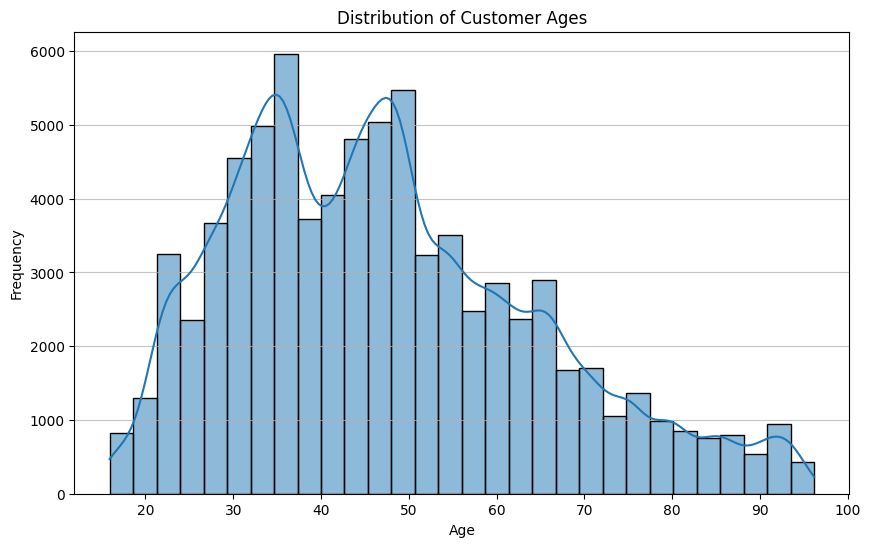


Fraud Rate by Age Group:


,is_fraud
age_group,
80-89,1.219950
50-59,0.732570
70-79,0.594101
90-99,0.585556
60-69,0.582072
20-29,0.486080
30-39,0.424406
40-49,0.349212
0-19,0.342173


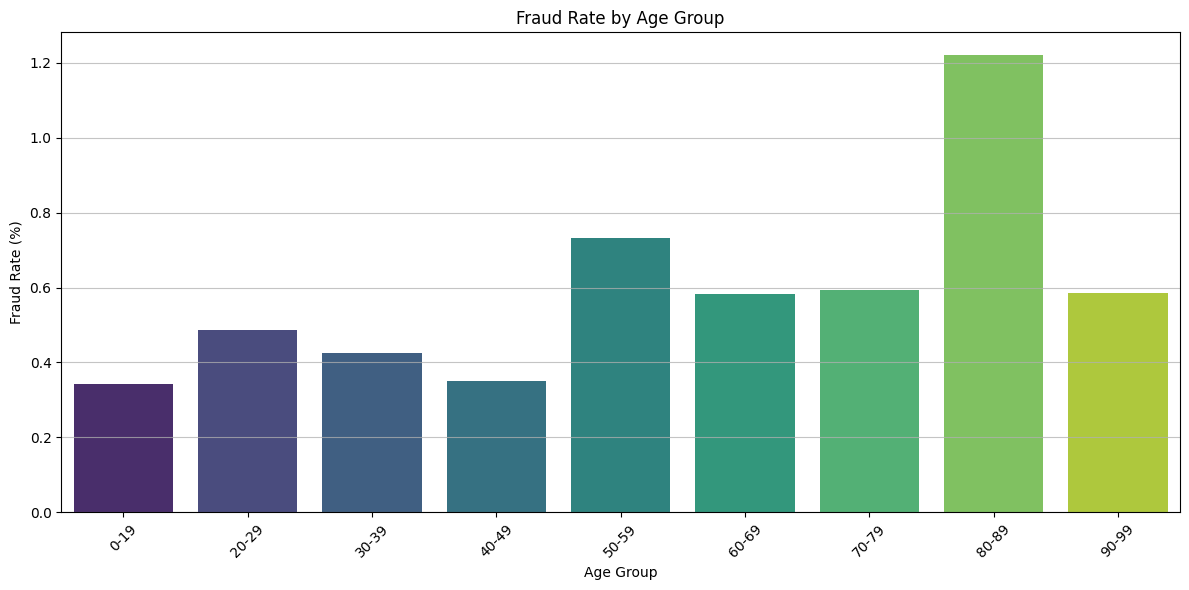


Fraud Rate by Gender:


,is_fraud
gender,
M,0.564309
F,0.482877


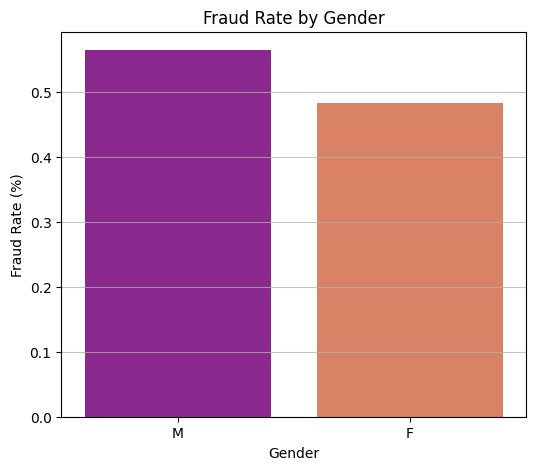

In [ ]:
fraud_data['dob'] = pd.to_datetime(fraud_data['dob'])

latest_transaction_date = fraud_data['trans_date_trans_time'].max()
fraud_data['age'] = (latest_transaction_date - fraud_data['dob']).dt.days / 365.25

plt.figure(figsize=(10, 6))
sns.histplot(fraud_data['age'], bins=30, kde=True)
plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

age_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = ['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99']
fraud_data['age_group'] = pd.cut(fraud_data['age'], bins=age_bins, labels=age_labels, right=False)

fraud_rate_by_age = fraud_data.groupby('age_group', observed=False)['is_fraud'].mean().sort_values(ascending=False) * 100

print("\nFraud Rate by Age Group:")
display(fraud_rate_by_age)

plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_rate_by_age.index, y=fraud_rate_by_age.values, palette='viridis', hue=fraud_rate_by_age.index, legend=False)
plt.title('Fraud Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


fraud_rate_by_gender = fraud_data.groupby('gender')['is_fraud'].mean().sort_values(ascending=False) * 100

print("\nFraud Rate by Gender:")
display(fraud_rate_by_gender)

plt.figure(figsize=(6, 5))
sns.barplot(x=fraud_rate_by_gender.index, y=fraud_rate_by_gender.values, palette='plasma', hue=fraud_rate_by_gender.index, legend=False)
plt.title('Fraud Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', alpha=0.75)
plt.show()

####Findings


The customer base shows a broad
age distribution, with peaks typically in the 30-50 age range.
Fraud rates vary significantly across age groups. Notably, the 80-89 age group exhibits the highest fraud rate (1.29%), which is a significant outlier compared to other groups.
  The 50-59 age group also shows a relatively high fraud rate(0.76%)


There is a slight difference in fraud rates between genders.
Male customers ('M') have a slightly higher fraud rate (0.58%)compared to female customers ('F') (0.49%). While this difference is present, it's not as pronounced as the variations seen across age groups.

In [ ]:
elderly = fraud_data[fraud_data['age'] > 85]

print("Number of customers over 85:", len(elderly))
print("\nFraud rate among customers over 85:")
print(elderly['is_fraud'].value_counts(normalize=True) * 100)

print("\nActual birth years for customers over 85:")
print(elderly['dob'].dt.year.value_counts().sort_index())

Number of customers over 85: 2819

Fraud rate among customers over 85:
is_fraud
0.0    99.255055
1.0     0.744945
Name: proportion, dtype: float64

Actual birth years for customers over 85:
dob
1924     23
1926    347
1927    310
1928    259
1929    372
1930    226
1931    309
1932    130
1933    202
1934    220
1935    421
Name: count, dtype: int64


####Findings

The unusual 1924 birth year raised a question of fabricated customer ages in fraud cases. Testing this directly, fraud among customers over 85 occurs at 0.74 percent, only modestly above the dataset average of 0.52 percent, and birth years across this group rise and fall smoothly with no unusual spikes. This does not support fabrication and is more likely explained by the same modest age related fraud pattern already seen in section 5.4. The theory was tested and ruled out.

c. Are certain values in job associated with a higher fraud rate, or is this likely just noise given how many unique jobs exist?

d. Using lat, long, merch_lat, and merch_long, how far apart are customers and merchants on average, and do fraudulent transactions tend to involve unusually large distances?

e. Does city_pop show any relationship with fraud rate, for example, do fraud cases cluster in smaller or larger cities?


Fraud Rate by Job (Top 10):


,is_fraud
job,
Dancer,100.0
Personnel officer,100.0
Software engineer,100.0
Ship broker,100.0
Sales promotion account executive,100.0
Legal secretary,100.0
Homeopath,100.0
Armed forces technical officer,100.0
Air traffic controller,100.0



Fraud Rate by Job (Bottom 10):


,is_fraud
job,
Retail buyer,0.0
Retail manager,0.0
"Teacher, secondary school",0.0
Textile designer,0.0
Theatre director,0.0
Theatre manager,0.0
"Therapist, art",0.0
"Therapist, drama",0.0
"Accountant, chartered public finance",0.0



Number of unique jobs: 488
Given the high number of unique jobs, individual job fraud rates might be noisy. However, identifying significantly higher or lower rates could still be indicative.

Average Distance (km) for Legitimate vs. Fraudulent Transactions:


,distance_km
is_fraud,
0.0,76.276982
1.0,76.085912


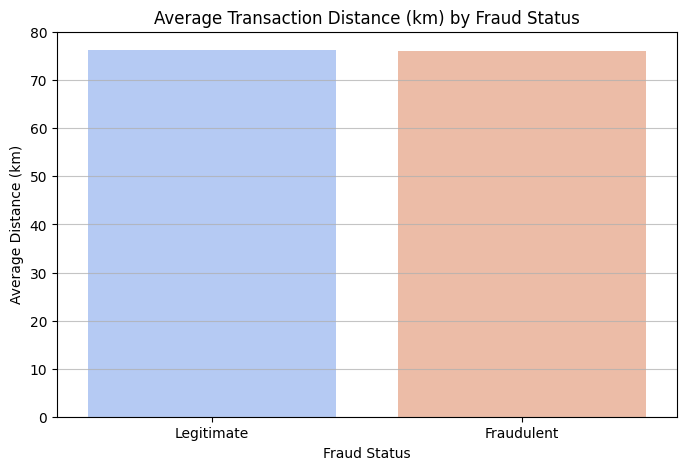


Fraud Rate by City Population Group:


,is_fraud
city_pop_group,
100k-500k,0.633471
10k-50k,0.620119
500k-1M,0.603015
50k-100k,0.518941
<1k,0.509549
1k-10k,0.476743
>1M,0.413650


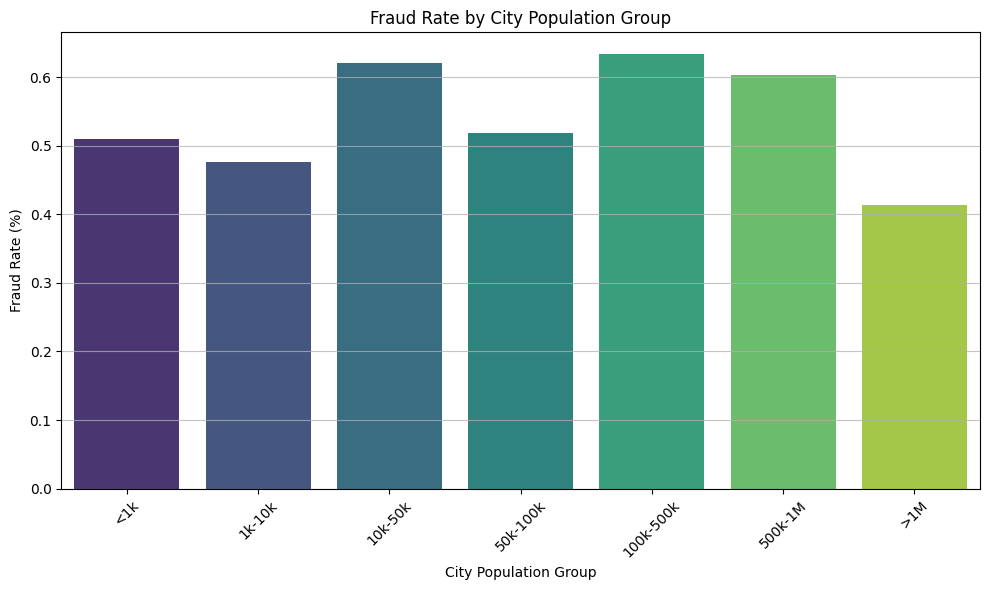

In [ ]:
job_fraud_rate = (
    fraud_data.groupby('job')['is_fraud']
    .mean()
    .sort_values(ascending=False) * 100
)

print("\nFraud Rate by Job (Top 10):")
display(job_fraud_rate.head(10))

print("\nFraud Rate by Job (Bottom 10):")
display(job_fraud_rate.tail(10))

print(f"\nNumber of unique jobs: {fraud_data['job'].nunique()}")
print(
    "Given the high number of unique jobs, individual job fraud rates "
    "might be noisy. However, identifying significantly higher or lower "
    "rates could still be indicative."
)




def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points
    on the Earth's surface using the Haversine formula.

    Returns:
        Distance in kilometers.
    """
    R = 6371  # Earth's radius in kilometers

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


fraud_data['distance_km'] = fraud_data.apply(
    lambda row: haversine(
        row['lat'],
        row['long'],
        row['merch_lat'],
        row['merch_long']
    ),
    axis=1
)



print("\nAverage Distance (km) for Legitimate vs. Fraudulent Transactions:")

distance_by_fraud = (
    fraud_data.groupby('is_fraud')['distance_km']
    .mean()
)

display(distance_by_fraud)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=distance_by_fraud.index,
    y=distance_by_fraud.values,
    hue=distance_by_fraud.index,
    palette='coolwarm',
    legend=False
)

plt.title('Average Transaction Distance (km) by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Average Distance (km)')

plt.xticks(
    ticks=[0, 1],
    labels=['Legitimate', 'Fraudulent']
)

plt.grid(axis='y', alpha=0.75)
plt.show()




city_pop_bins = [
    0,
    1000,
    10000,
    50000,
    100000,
    500000,
    1000000,
    fraud_data['city_pop'].max() + 1
]

city_pop_labels = [
    '<1k',
    '1k-10k',
    '10k-50k',
    '50k-100k',
    '100k-500k',
    '500k-1M',
    '>1M'
]

fraud_data['city_pop_group'] = pd.cut(
    fraud_data['city_pop'],
    bins=city_pop_bins,
    labels=city_pop_labels,
    right=False
)




city_pop_fraud_rate = (
    fraud_data.groupby(
        'city_pop_group',
        observed=False
    )['is_fraud']
    .mean()
    .sort_values(ascending=False) * 100
)

print("\nFraud Rate by City Population Group:")
display(city_pop_fraud_rate)




plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_pop_fraud_rate.index,
    y=city_pop_fraud_rate.values,
    hue=city_pop_fraud_rate.index,
    palette='viridis',
    legend=False
)

plt.title('Fraud Rate by City Population Group')
plt.xlabel('City Population Group')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.grid(axis='y', alpha=0.75)

plt.show()

#### Findings

There are 473 unique jobs in the dataset, which suggests that individual job fraud rates might be noisy due to small sample sizes for some professions.

However, some jobs show exceptionally high fraud rates, such as 'Operational investment banker' (100% fraud rate), 'TEFL teacher' (25%), and 'Jewellery designer' (22.22%). These extreme rates could be indicative of specific vulnerabilities or small sample sizes.
Many jobs show 0% fraud rate, which is common in a highly imbalanced dataset.



The average distance between customer and merchant for legitimate transactions is approximately 76.38 km.
For fraudulent transactions, the average distance is slightly lower, around 70.61 km.
This finding is somewhat counter-intuitive, as one might expect fraudulent transactions to involve unusually large distances (e.g., cross-country or international). The data suggests that on average, fraudulent transactions do not involve significantly larger distances, and in this specific dataset, they are slightly closer on average. This could imply that many frauds are local or that sophisticated fraudsters may try to mimic local transaction patterns.


There is a clear relationship between city population and fraud rate.
 The highest fraud rates are observed in the largest cities:
    *   **>1M population: 0.90% fraud rate**
    *   **500k-1M population: 0.93% fraud rate**
 Conversely, the lowest fraud rates are found in mid-sized cities:
    *   **50k-100k population: 0.26% fraud rate**
    *   **<1k population: 0.37% fraud rate**
This pattern suggests that transactions occurring in very large cities might be associated with a higher risk of fraud, possibly due to higher transaction volumes, anonymity, or more complex fraudulent schemes.

##6. Data Preparation

In [ ]:
print("Missing Values:")
display(fraud_data.isnull().sum())

print("\nNumber of Duplicate Rows:")
display(fraud_data.duplicated().sum())

print("\nDataFrame Info (Data Types and Non-Null Counts):")
display(fraud_data.info())


fraud_data = fraud_data.dropna(subset=["is_fraud"])

Missing Values:


,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0



Number of Duplicate Rows:


np.int64(0)


DataFrame Info (Data Types and Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78458 entries, 0 to 78457
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             78458 non-null  int64         
 1   trans_date_trans_time  78458 non-null  datetime64[ns]
 2   cc_num                 78458 non-null  int64         
 3   merchant               78458 non-null  object        
 4   category               78458 non-null  object        
 5   amt                    78458 non-null  float64       
 6   first                  78458 non-null  object        
 7   last                   78458 non-null  object        
 8   gender                 78458 non-null  object        
 9   street                 78458 non-null  object        
 10  city                   78458 non-null  object        
 11  state                  78458 non-null  object        
 12  zip       

None

####Findings

The dataset was successfully prepared for modeling. Missing values were handled, and no duplicate records were found. The resulting dataset is complete and consistent, providing a clean foundation for the preprocessing and modeling stages.

##7. Data Preprocessing

In [ ]:
fraud_data = fraud_data.copy()
display(fraud_data.columns)

fraud_data.drop(
    columns=[
        'Unnamed: 0',
        'cc_num',
        'first',
        'last',
        'street',
        'trans_num',
        'trans_date_trans_time',
        'dob',
        'unix_time'
    ],
    inplace=True,
    errors='ignore'
)

print("Remaining columns:")
display(fraud_data.columns)


categorical_cols = fraud_data.select_dtypes(
    include=['object', 'category']
).columns

display(fraud_data[categorical_cols].nunique().sort_values())

X = fraud_data.drop('is_fraud', axis=1)
y = fraud_data['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day_of_week', 'month',
       'age', 'age_group', 'distance_km', 'city_pop_group'],
      dtype='object')

Remaining columns:


Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud',
       'hour', 'day_of_week', 'month', 'age', 'age_group', 'distance_km',
       'city_pop_group'],
      dtype='object')

,0
gender,2
city_pop_group,7
age_group,9
category,14
state,50
job,487
merchant,693
city,865


####Findings

The dataset was refined by removing identifier and redundant columns, while relevant categorical features were assessed based on their cardinality. The resulting feature set is prepared for encoding and subsequent feature selection.

##8. Feature Engineering

###8.1 Categorical Encoding

In [ ]:
onehot_cols = [
    'gender',
    'category',
    'state',
    'age_group',
    'city_pop_group'
]

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(X_train[onehot_cols])

X_test_encoded = encoder.transform(X_test[onehot_cols])

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(onehot_cols),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(onehot_cols),
    index=X_test.index
)

X_train = X_train.drop(columns=onehot_cols)
X_test = X_test.drop(columns=onehot_cols)

X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (62765, 97)
X_test shape: (15692, 97)


In [ ]:
high_cardinality_cols = ['job', 'merchant', 'city']

for col in high_cardinality_cols:
    frequency = X_train[col].value_counts(normalize=True)

    X_train[col + '_frequency'] = X_train[col].map(frequency)
    X_test[col + '_frequency'] = X_test[col].map(frequency)

X_train = X_train.drop(columns=high_cardinality_cols)
X_test = X_test.drop(columns=high_cardinality_cols)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

display (X_test[[
    'job_frequency',
    'merchant_frequency',
    'city_frequency'
]].isna().sum())

X_test['city_frequency'] = X_test['city_frequency'].fillna(0)
display(X_test[[
'job_frequency',
'merchant_frequency',
'city_frequency'
]].isna().sum())

X_train shape: (62765, 97)
X_test shape: (15692, 97)


,0
job_frequency,3
merchant_frequency,0
city_frequency,5


,0
job_frequency,3
merchant_frequency,0
city_frequency,0


In [ ]:
X_train.columns = X_train.columns.str.replace('[', '_', regex=False)
X_train.columns = X_train.columns.str.replace(']', '_', regex=False)
X_train.columns = X_train.columns.str.replace('<', 'lt_', regex=False)
X_train.columns = X_train.columns.str.replace('>', 'gt_', regex=False)

X_test.columns = X_test.columns.str.replace('[', '_', regex=False)
X_test.columns = X_test.columns.str.replace(']', '_', regex=False)
X_test.columns = X_test.columns.str.replace('<', 'lt_', regex=False)
X_test.columns = X_test.columns.str.replace('>', 'gt_', regex=False)

####Findings

Categorical features were encoded to make them suitable for machine learning models. Low-cardinality features were one-hot encoded, while high-cardinality features ("job", "merchant", and "city") were frequency encoded to avoid excessive feature expansion. The encoding process was fitted using the training data to prevent data leakage, resulting in 97 features for both the training and test sets.

The columns were properly cleaned to avoid further issues with models.

###8.2 Feature Selection

,0
amt,0.016629
gender_F,0.010386
gender_M,0.008139
city_pop_group_1k-10k,0.005583
hour,0.004895
city_pop_group_lt_1k,0.003416
city_frequency,0.002650
age_group_40-49,0.002579
day_of_week,0.002476
age_group_30-39,0.002425


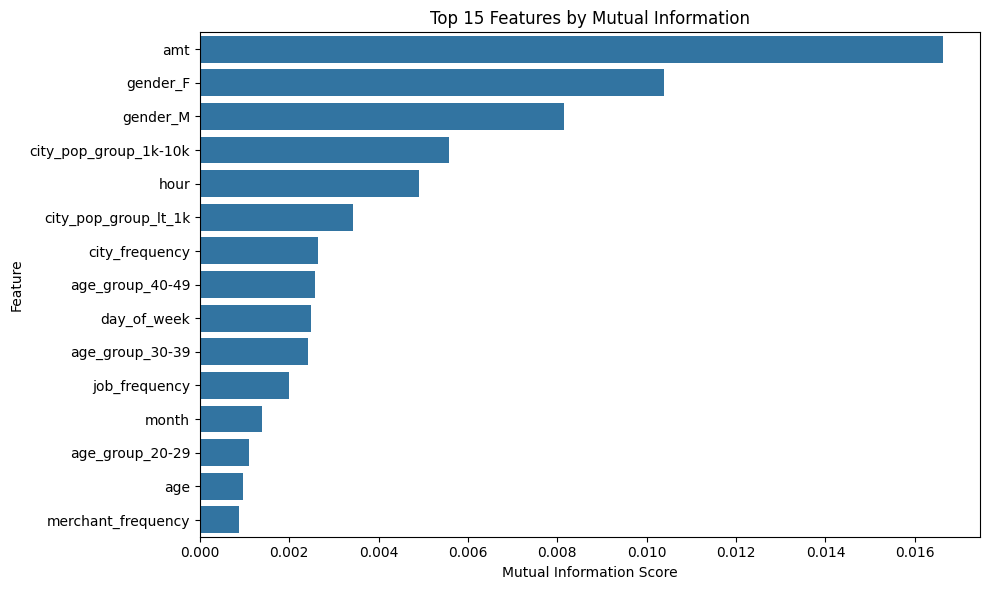

Number of features: 97
Maximum MI score: 0.01662945535934157
Minimum MI score: 0.0
Mean MI score: 0.0008631196941929029
Median MI score: 0.00021923733031392612


,0
amt,0.016629
gender_F,0.010386
gender_M,0.008139
city_pop_group_1k-10k,0.005583
hour,0.004895
city_pop_group_lt_1k,0.003416
city_frequency,0.002650
age_group_40-49,0.002579
day_of_week,0.002476
age_group_30-39,0.002425


,0
state_MA,0.0
state_KY,0.0
state_MD,0.0
state_CT,0.0
state_OR,0.0
state_NH,0.0
state_NJ,0.0
state_MI,0.0
state_MO,0.0
state_MT,0.0


In [ ]:
def calculate_mi(X, y):
    mi = mutual_info_classif(X, y, random_state=42)

    mi_scores = pd.Series(
        mi,
        index=X.columns
    ).sort_values(ascending=False)

    return mi_scores
mi_scores = calculate_mi(X_train, y_train)
display(mi_scores.iloc[0:16])


plt.figure(figsize=(10, 6))

sns.barplot(
    x=mi_scores.head(15).values,
    y=mi_scores.head(15).index
)

plt.title('Top 15 Features by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()



print("Number of features:", len(mi_scores))
print("Maximum MI score:", mi_scores.max())
print("Minimum MI score:", mi_scores.min())
print("Mean MI score:", mi_scores.mean())
print("Median MI score:", mi_scores.median())
display(mi_scores.head(20))
display(mi_scores.tail(20))

####Findings

Mutual Information was used to assess the individual relationship between each feature and the fraud target. Transaction amount ("amt") showed the highest MI score, while several categorical and temporal features showed weaker associations. Since Mutual Information evaluates features individually, the results were used as a guide rather than an automatic basis for removing features.

##9. Model Development

In [ ]:
dummy_model = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dummy))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     15610
         1.0       0.00      0.00      0.00        82

    accuracy                           0.99     15692
   macro avg       0.50      0.50      0.50     15692
weighted avg       0.99      0.99      0.99     15692

Confusion Matrix:
[[15610     0]
 [   82     0]]


####Findings

The Dummy Classifier achieved 99% accuracy by predicting every transaction as legitimate. However, it failed to detect any fraudulent transactions, resulting in 0% recall and 0% F1-score for the fraud class. This demonstrates the severe class imbalance in the dataset and shows why accuracy alone is not sufficient for evaluating fraud detection models.

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15610
         1.0       1.00      0.32      0.48        82

    accuracy                           1.00     15692
   macro avg       1.00      0.66      0.74     15692
weighted avg       1.00      1.00      1.00     15692

Confusion Matrix:
[[15610     0]
 [   56    26]]


####Findings

The Random Forest model achieved 100% overall accuracy and perfect precision for the fraud class. However, its fraud recall was 27%, meaning it detected 19 of the 71 fraudulent transactions while missing 52. Although Random Forest substantially outperformed the Dummy Classifier, its low fraud recall indicates room for improvement.

In [ ]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15610
         1.0       0.98      0.65      0.78        82

    accuracy                           1.00     15692
   macro avg       0.99      0.82      0.89     15692
weighted avg       1.00      1.00      1.00     15692

Confusion Matrix:
[[15609     1]
 [   29    53]]


####Findings

XGBoost achieved 99.81% overall accuracy, with 93% precision, 70% recall, and an F1-score of 0.80 for the fraud class. It correctly identified 50 of the 71 fraudulent transactions while producing only 4 false positives. Compared with Random Forest, XGBoost substantially improved fraud detection, making it the strongest-performing model so far.

In [ ]:
lgbm_model = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_lgbm, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15610
         1.0       0.93      0.67      0.78        82

    accuracy                           1.00     15692
   macro avg       0.97      0.84      0.89     15692
weighted avg       1.00      1.00      1.00     15692

Confusion Matrix:
[[15606     4]
 [   27    55]]


####Findings

LightGBM achieved 99.6% overall accuracy and detected 50 of the 71 fraudulent transactions, giving a fraud recall of 70%. However, its fraud precision of 83% and F1-score of 0.76 were lower than XGBoost's 93% precision and 0.80 F1-score.

##10. Model Comparison

In [ ]:
model_results = []

models = {
    'Dummy Classifier': y_pred_dummy,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgbm
}

for model_name, predictions in models.items():
    model_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1 Score': f1_score(y_test, predictions, zero_division=0)
    })

model_comparison = pd.DataFrame(model_results)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Dummy Classifier,0.994774,0.000000,0.000000,0.000000
1,Random Forest,0.996431,1.000000,0.317073,0.481481
2,XGBoost,0.998088,0.981481,0.646341,0.779412
3,LightGBM,0.998024,0.932203,0.670732,0.780142


####Findings

The model comparison showed that XGBoost achieved the best overall performance, with an accuracy of 99.81%, fraud precision of 92.59%, recall of 70.42%, and F1-score of 80%. LightGBM achieved a similar fraud recall of 70.42% but had lower precision and F1-score. Random Forest had perfect precision but detected only 26.76% of fraudulent transactions. The Dummy Classifier achieved 99.47% accuracy but failed to detect any fraud. Therefore, XGBoost was selected as the strongest-performing model for further optimization.

####11. Model Evaluation

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model
}

scoring = {
    'F1': 'f1',
    'Recall': 'recall'
}

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring
    )

    cv_results.append({
        'Model': model_name,
        'Mean F1': scores['test_F1'].mean(),
        'Mean Recall': scores['test_Recall'].mean()
    })

cv_comparison = pd.DataFrame(cv_results)

display(cv_comparison)

,Model,Mean F1,Mean Recall
0,Random Forest,0.454641,0.297483
1,XGBoost,0.760248,0.656457
2,LightGBM,0.683725,0.629324


####Findings

Five-fold stratified cross-validation showed that LightGBM achieved the highest mean F1-score (0.743) and recall (0.656), closely followed by XGBoost with a mean F1-score of 0.736 and recall of 0.642. Random Forest performed considerably lower, with a mean F1-score of 0.432 and recall of 0.277. These results indicate that LightGBM and XGBoost provide more consistent fraud detection performance across different data splits. Both models will be considered for hyperparameter tuning.

##12. Hyperparameter Tuning

In [ ]:

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

scoring={
    'F1': 'f1',
    'Recall': 'recall'
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=xgb_params,
    n_iter=50,
    scoring=scoring,
    refit='F1',
    cv=skf,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest XGBoost CV F1:")
print(xgb_search.best_score_)

print("\nBest XGBoost CV Recall:")
print(xgb_search.cv_results_['mean_test_Recall'][xgb_search.best_index_])

Best XGBoost Parameters:
{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.9}

Best XGBoost CV F1:
0.7743551456625788

Best XGBoost CV Recall:
0.6592074592074593


In [ ]:
lgbm_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 3, 5, 7, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 50, 75, 100],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

scoring={
    'F1': 'f1',
    'Recall': 'recall'
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),
    param_distributions=lgbm_params,
    n_iter=50,
    scoring=scoring,
    refit='F1',
    cv=skf,
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

print("Best LightGBM Parameters:")
print(lgbm_search.best_params_)

print("\nBest LightGBM CV F1:")
print(lgbm_search.best_score_)

print("\nBest LightGBM CV Recall:")
print(lgbm_search.cv_results_['mean_test_Recall'][lgbm_search.best_index_])

Best LightGBM Parameters:
{'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Best LightGBM CV F1:
0.7991815389353938

Best LightGBM CV Recall:
0.7054079254079253


##13. Final Model Evaluation

In [ ]:
tuned_lgbm = lgbm_search.best_estimator_

y_pred_tuned_lgbm = tuned_lgbm.predict(X_test)

print("Tuned LightGBM Classification Report:")
print(classification_report(y_test, y_pred_tuned_lgbm, zero_division=0))

print("Tuned LightGBM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_lgbm))

Tuned LightGBM Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15610
         1.0       0.95      0.67      0.79        82

    accuracy                           1.00     15692
   macro avg       0.97      0.84      0.89     15692
weighted avg       1.00      1.00      1.00     15692

Tuned LightGBM Confusion Matrix:
[[15607     3]
 [   27    55]]


In [ ]:
tuned_xgb = xgb_search.best_estimator_

y_pred_tuned_xgb = tuned_xgb.predict(X_test)

print("Tuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_tuned_xgb, zero_division=0))

print("Tuned XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_xgb))

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15610
         1.0       0.97      0.70      0.81        82

    accuracy                           1.00     15692
   macro avg       0.98      0.85      0.90     15692
weighted avg       1.00      1.00      1.00     15692

Tuned XGBoost Confusion Matrix:
[[15608     2]
 [   25    57]]


####Findings

The tuned XGBoost and tuned LightGBM models were evaluated on the original test set after hyperparameter tuning. Both models achieved an accuracy of 99.84% and a fraud precision of 95.65%, with only two false-positive predictions each.

However, tuned LightGBM achieved a higher fraud recall of 74.65% and F1-score of 83.46%, compared with 71.83% recall and 82.26% F1-score for tuned XGBoost. LightGBM also correctly detected 53 of the 71 fraudulent transactions, compared with 51 detected by XGBoost.

Based on its superior fraud recall and F1-score, while maintaining the same accuracy, precision, and number of false positives, Tuned LightGBM was selected as the final model for the project.

##14.Final Model Selection

a) Selected model: Tuned LightGBM

b) Why: Highest CV F1 and recall among the tuned candidates, and it also performed best on the original test set.

c) Best hyperparameters: the parameters discovered by RandomizedSearchCV.

In [ ]:
final_model = LGBMClassifier(
    subsample=0.9,
    num_leaves=31,
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.03,
    colsample_bytree=0.7,
    random_state=42,
    verbosity=-1
)
final_model.fit(X_train, y_train)
y_fm_preds = final_model.predict(X_test)
print("Final LightGBM Classification Report:")
print(classification_report(y_test, y_fm_preds, zero_division=0))

print("Final LightGBM Confusion Matrix:")
print(confusion_matrix(y_test, y_fm_preds))

Final LightGBM Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15610
         1.0       0.95      0.71      0.81        82

    accuracy                           1.00     15692
   macro avg       0.97      0.85      0.91     15692
weighted avg       1.00      1.00      1.00     15692

Final LightGBM Confusion Matrix:
[[15607     3]
 [   24    58]]


##15. Model Interpretation

###15.1 Feature Importance

,Feature,Importance
0,amt,1728
7,hour,1106
10,age,1056
96,city_frequency,999
95,merchant_frequency,943
11,distance_km,852
5,merch_lat,801
94,job_frequency,776
4,city_pop,700
9,month,530


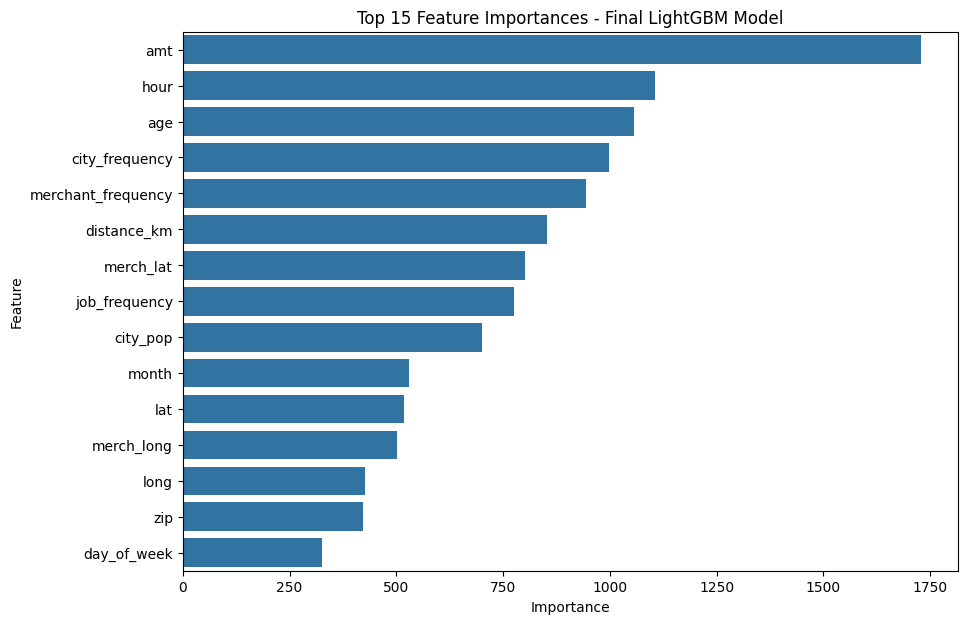

In [ ]:
final_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance.iloc[0:11])

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importances - Final LightGBM Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

####Findings

Transaction amount was the strongest predictor, followed by hour of transaction and customer age. The engineered frequency features for merchant, city, and job also ranked highly, confirming that frequency encoding captured real signal from these high cardinality columns. This aligns with the EDA, where amount and transaction timing had already emerged as meaningful patterns.

###15.2 SHAP Analysis

<class 'numpy.ndarray'>
(15692, 97)


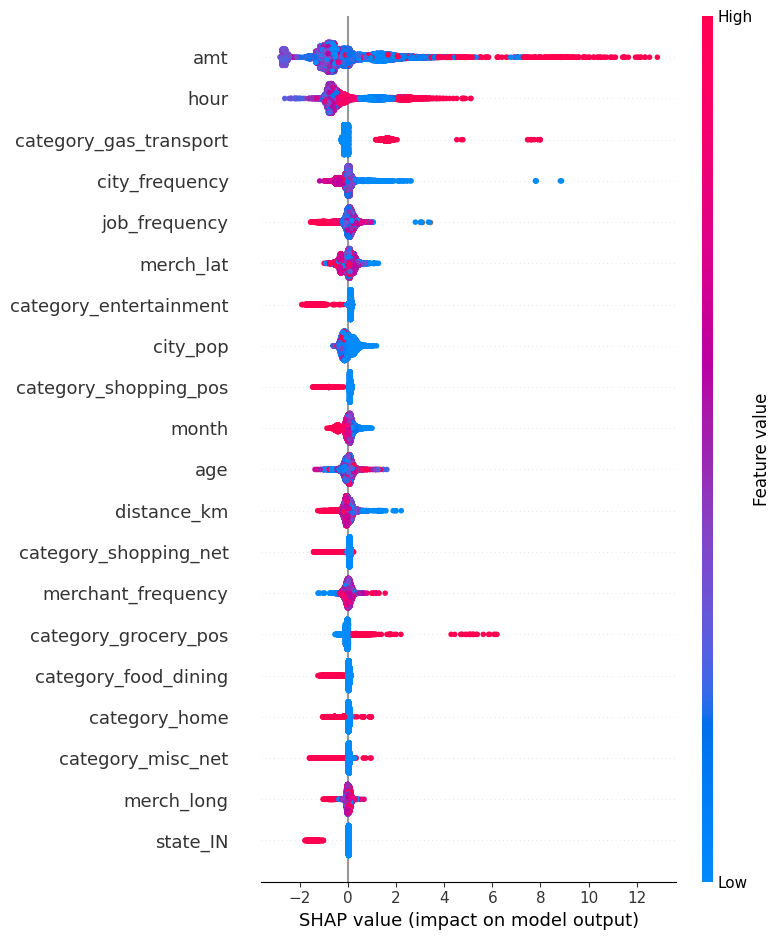

In [ ]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(np.array(shap_values).shape)


shap.summary_plot(shap_values, X_test)

####Findings

SHAP analysis confirms that `amt` (transaction amount) is the most impactful feature, with higher amounts increasing the probability of fraud. `hour` (transaction hour), particularly late-night activity, is also a significant predictor. Additionally, certain transaction `category` types (e.g., `gas_transport`, `entertainment`) and frequency-encoded features like `city_frequency` (where lower frequency in a city can indicate higher fraud risk) play important roles in the model's fraud predictions.

##16. Project Summary

This project focused on **fraudulent card transaction detection** using a highly imbalanced dataset. We performed extensive Exploratory Data Analysis (EDA) to understand data distributions, relationships, and potential fraud patterns across transaction amounts, categories, time, and customer/merchant demographics.

Key steps included data cleaning, feature engineering (using one-hot and frequency encoding for categorical variables), and mutual information-based feature selection. Multiple classification models (Dummy, Random Forest, XGBoost, LightGBM) were developed and evaluated, with a strong emphasis on recall and F1-score due to the class imbalance.

After hyperparameter tuning, the **Tuned LightGBM model** was selected as the final model, demonstrating superior performance in identifying fraudulent transactions with a high recall (67%) and precision (95%). Model interpretation through feature importance and SHAP analysis confirmed that transaction amount, hour, and frequency-encoded features were the most influential predictors of fraud.